# Байесовский вывод. Наивная байесовская классификация

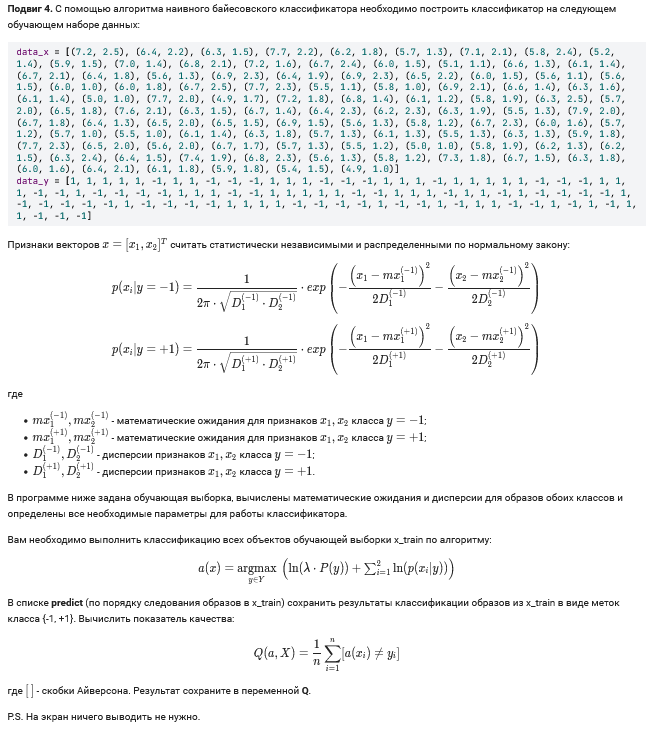

In [16]:
import numpy as np

data_x = [(7.2, 2.5), (6.4, 2.2), (6.3, 1.5), (7.7, 2.2), (6.2, 1.8), (5.7, 1.3), (7.1, 2.1), (5.8, 2.4), (5.2, 1.4), (5.9, 1.5), (7.0, 1.4), (6.8, 2.1), (7.2, 1.6), (6.7, 2.4), (6.0, 1.5), (5.1, 1.1), (6.6, 1.3), (6.1, 1.4), (6.7, 2.1), (6.4, 1.8), (5.6, 1.3), (6.9, 2.3), (6.4, 1.9), (6.9, 2.3), (6.5, 2.2), (6.0, 1.5), (5.6, 1.1), (5.6, 1.5), (6.0, 1.0), (6.0, 1.8), (6.7, 2.5), (7.7, 2.3), (5.5, 1.1), (5.8, 1.0), (6.9, 2.1), (6.6, 1.4), (6.3, 1.6), (6.1, 1.4), (5.0, 1.0), (7.7, 2.0), (4.9, 1.7), (7.2, 1.8), (6.8, 1.4), (6.1, 1.2), (5.8, 1.9), (6.3, 2.5), (5.7, 2.0), (6.5, 1.8), (7.6, 2.1), (6.3, 1.5), (6.7, 1.4), (6.4, 2.3), (6.2, 2.3), (6.3, 1.9), (5.5, 1.3), (7.9, 2.0), (6.7, 1.8), (6.4, 1.3), (6.5, 2.0), (6.5, 1.5), (6.9, 1.5), (5.6, 1.3), (5.8, 1.2), (6.7, 2.3), (6.0, 1.6), (5.7, 1.2), (5.7, 1.0), (5.5, 1.0), (6.1, 1.4), (6.3, 1.8), (5.7, 1.3), (6.1, 1.3), (5.5, 1.3), (6.3, 1.3), (5.9, 1.8), (7.7, 2.3), (6.5, 2.0), (5.6, 2.0), (6.7, 1.7), (5.7, 1.3), (5.5, 1.2), (5.0, 1.0), (5.8, 1.9), (6.2, 1.3), (6.2, 1.5), (6.3, 2.4), (6.4, 1.5), (7.4, 1.9), (6.8, 2.3), (5.6, 1.3), (5.8, 1.2), (7.3, 1.8), (6.7, 1.5), (6.3, 1.8), (6.0, 1.6), (6.4, 2.1), (6.1, 1.8), (5.9, 1.8), (5.4, 1.5), (4.9, 1.0)]
data_y = [1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, 1, 1, 1, -1, -1, -1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, -1, -1, 1, 1, 1, -1, -1, 1, -1, -1, -1, -1, 1, 1, 1, -1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, -1, 1, -1, -1, -1, -1, -1, 1, -1, -1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1, 1, -1, -1, 1, -1, 1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, -1, -1]

x_train = np.array(data_x)
y_train = np.array(data_y)

# математические ожидания
mx11, mx12 = np.mean(x_train[y_train == -1], axis=0)
mx21, mx22 = np.mean(x_train[y_train == 1], axis=0)

# дисперсии
Dx11, Dx12 = np.var(x_train[y_train == -1], axis=0)
Dx21, Dx22 = np.var(x_train[y_train == 1], axis=0)

lm1 = 1     # штраф неверной классификации 1-го класса (-1)
lm2 = 1     # штраф неверной классификации 2-го класса (+1)
P1 = 0.5    # априорная вероятность появления образов 1-го класса
P2 = 1 - P1 # априорная вероятность появления образов 2-го класса

p_xy = lambda x, mx1, mx2, D1, D2: 1 / (2 * np.pi * D1 * D2) * np.exp(-(x[0] - mx1)**2 / (2 * D1) - (x[1] - mx2)**2 / (2 * D2))

def a(x, lm1, lm2, P1, P2):
    p_xy_m1 = p_xy(x, mx11, mx12, Dx11, Dx12)
    p_xy_p1 = p_xy(x, mx21, mx22, Dx21, Dx22)
    return 2 * (np.log(p_xy_m1 * P1) - np.log(lm1) < np.log(p_xy_p1 * P2) - np.log(lm2)) - 1

# здесь продолжайте программу
predict = np.array([a(x, lm1, lm2, P1, P2) for x in x_train])
Q = np.mean(y_train != predict)

print(predict)
print(Q)

[ 1  1 -1  1  1 -1  1  1 -1 -1 -1  1  1  1 -1 -1 -1 -1  1  1 -1  1  1  1
  1 -1 -1 -1 -1  1  1  1 -1 -1  1 -1 -1 -1 -1  1 -1  1 -1 -1  1  1  1  1
  1 -1 -1  1  1  1 -1  1  1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1  1 -1 -1
 -1 -1  1  1  1  1  1 -1 -1 -1  1 -1 -1  1 -1  1  1 -1 -1  1 -1  1 -1  1
  1  1 -1 -1]
0.06


In [4]:
def classify(x, mx11, mx12, Dx11, Dx12, mx21, mx22, Dx21, Dx22, lm1=1, lm2=1, P1=0.5):
    # p(x | класс -1)
    p_m1 = 1 / (2 * np.pi * Dx11 * Dx12) * np.exp(
        -(x[0] - mx11)**2 / (2 * Dx11) - (x[1] - mx12)**2 / (2 * Dx12))
    
    # p(x | класс +1)  
    p_p1 = 1 / (2 * np.pi * Dx21 * Dx22) * np.exp(
        -(x[0] - mx21)**2 / (2 * Dx21) - (x[1] - mx22)**2 / (2 * Dx22))
    
    # MAP scores (log posterior ∝ log prior * likelihood / loss)
    score_m1 = np.log(P1 * p_m1) - np.log(lm1)  # класс -1
    score_p1 = np.log((1-P1) * p_p1) - np.log(lm2)  # класс +1
    
    return -1 if score_m1 > score_p1 else 1

predict = np.array([classify(x_train[i], mx11, mx12, Dx11, Dx12, mx21, mx22, Dx21, Dx22) for i in range(len(x_train))])
Q = np.mean(y_train != predict)

print(predict)
print(Q)

[ 1  1 -1  1  1 -1  1  1 -1 -1 -1  1  1  1 -1 -1 -1 -1  1  1 -1  1  1  1
  1 -1 -1 -1 -1  1  1  1 -1 -1  1 -1 -1 -1 -1  1 -1  1 -1 -1  1  1  1  1
  1 -1 -1  1  1  1 -1  1  1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1  1 -1 -1
 -1 -1  1  1  1  1  1 -1 -1 -1  1 -1 -1  1 -1  1  1 -1 -1  1 -1  1 -1  1
  1  1 -1 -1]
0.06
